<a href="https://colab.research.google.com/github/Linqiaoqiao2/xAI_Project_DG_Test-Time-Augmentation/blob/no_domainbed_baseline/DG_Baseline_no_domainbed.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# !pip install pillow numpy
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import transforms, models
from torch.utils.data import DataLoader, Dataset, ConcatDataset
import numpy as np
import os
import zipfile
from PIL import Image
from tqdm.notebook import tqdm # Progress bars

#Check if GPU is available
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {DEVICE}")

#For reproducibility
torch.manual_seed(42)
np.random.seed(42)
if DEVICE == 'cuda':
    torch.cuda.manual_seed_all(42)
PACS_DOMAINS = ['art_painting', 'cartoon', 'photo', 'sketch']
PACS_CATEGORIES = ['dog', 'elephant', 'giraffe', 'guitar', 'horse', 'house', 'person']

#Hyperparameters

MODEL_CHOICE = 'resnet18'
PRETRAINED = True
NUM_EPOCHS = 10
BATCH_SIZE = 32
LEARNING_RATE = 3e-5

#Identify logs/models when saving
print(f"Using device: {DEVICE}, Model: {MODEL_CHOICE}, Epochs: {NUM_EPOCHS}, Batch: {BATCH_SIZE}, LR: {LEARNING_RATE}")


Using device: cuda
Using device: cuda, Model: resnet18, Epochs: 10, Batch: 32, LR: 3e-05


---

### Cell 2: Download and Prepare PACS Dataset


In [2]:
# Load and Extract PACS Dataset

import os
import zipfile
from google.colab import drive

# Configuration
GOOGLE_DRIVE_FILE_PATH = "/content/drive/MyDrive/Colab Notebooks/PACS.zip"
COLAB_ZIP_NAME = "PACS.zip"
BASE_PACS_PATH = "kfold"

# 1. Mount Google Drive
drive.mount('/content/drive', force_remount=True)

# 2. Copy from Google Drive
os.system(f"cp '{GOOGLE_DRIVE_FILE_PATH}' {COLAB_ZIP_NAME}")

# 3. Unzip
with zipfile.ZipFile(COLAB_ZIP_NAME, 'r') as zip_ref:
    zip_ref.extractall(".") # Extract to current directory

# Print BASE_PACS_PATH
print(f"Dataset base path is configured as: '{BASE_PACS_PATH}'")

Mounted at /content/drive
Dataset base path is configured as: 'kfold'


---

### Cell 3: PACS_Dataset Class and Transformations





In [3]:
from pathlib import Path

class PACS_Dataset(Dataset):
    def __init__(self, base_path, domain_name, categories, transform=None):
        self.transform = transform
        self.image_paths = []
        self.labels = []
        for label_idx, category in enumerate(categories):
            category_path = os.path.join(base_path, domain_name, category)
            if not os.path.isdir(category_path):
                continue
            for img_file in os.listdir(category_path):
                if img_file.lower().endswith(('.jpg', '.jpeg', '.png')):
                    self.image_paths.append(os.path.join(category_path, img_file))
                    self.labels.append(label_idx)

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        img = Image.open(self.image_paths[idx]).convert('RGB')
        label = self.labels[idx]
        if self.transform:
            img = self.transform(img)
        return img, label

# Data Transformations
mean = [0.485, 0.456, 0.406]
std = [0.229, 0.224, 0.225]

# Train transform (no data augmentation)
train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean, std)
])

val_test_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean, std)
])

---

### Cell 4: Model Definition (ResNet 18)

In [4]:
def get_model(num_classes=len(PACS_CATEGORIES), pretrained=True):
    # Load the ResNet18 model
    model = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1 if pretrained else None)

    # Replace the final fully connected layer to match the number of target classes
    num_ftrs = model.fc.in_features
    model.fc = nn.Linear(num_ftrs, num_classes)
    return model

# Test model
try:
    test_model = get_model(num_classes=len(PACS_CATEGORIES))
    print("Model created successfully.")
except Exception as e:
    print(f"Error creating model: {e}")

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth
100%|██████████| 44.7M/44.7M [00:00<00:00, 119MB/s]


Model created successfully.


---

### Cell 5: Training and Evaluation Functions

In [5]:
# Training Function
def train_one_epoch(model, dataloader, criterion, optimizer, device):
    model.train()
    running_loss, correct, total = 0.0, 0, 0
    for inputs, labels in tqdm(dataloader, desc="Train", leave=False):
        inputs, labels = inputs.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item() * inputs.size(0)
        preds = outputs.argmax(1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)
    return running_loss / total, correct / total

# Evaluation Function
def eval_one_epoch(model, dataloader, criterion, device):
    model.eval()
    running_loss, correct, total = 0.0, 0, 0
    with torch.no_grad():
        for inputs, labels in tqdm(dataloader, desc="Val", leave=False):
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            running_loss += loss.item() * inputs.size(0)
            preds = outputs.argmax(1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)
    return running_loss / total, correct / total


---

### Cell 6: Leave-One-Domain-Out Evaluation Pipeline

In [8]:
import json
import os
import shutil
import torch
from torch.utils.data import DataLoader

# Mount Google Drive to store results
from google.colab import drive
drive.mount('/content/drive')

# Define save path inside Google Drive
SAVE_ROOT = "/content/drive/MyDrive/NLP project ss25/results/models"
os.makedirs(SAVE_ROOT, exist_ok=True)

BASE_PACS_PATH = "kfold"
all_accuracies = []
best_model_paths = []

# Leave-One-Domain-Out training loop
for target_domain in PACS_DOMAINS:
    print(f"\n===== Target Domain = {target_domain} =====")
    source_domains = [d for d in PACS_DOMAINS if d != target_domain]

    # Combine source domain datasets
    train_datasets = [
        PACS_Dataset(BASE_PACS_PATH, d, PACS_CATEGORIES, transform=train_transform)
        for d in source_domains
    ]
    train_dataset = torch.utils.data.ConcatDataset(train_datasets)
    train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=2)

    # Load test dataset from the target domain
    test_dataset = PACS_Dataset(BASE_PACS_PATH, target_domain, PACS_CATEGORIES, transform=val_test_transform)
    test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)

    # Initialize model, loss, and optimizer
    model = get_model(len(PACS_CATEGORIES), PRETRAINED).to(DEVICE)
    criterion = torch.nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE, weight_decay=1e-4)

    best_val_acc = 0.0
    best_model_path = os.path.join(SAVE_ROOT, f"best_model_target_{target_domain}.pth")

    # Train for multiple epochs, save the best model per domain
    for epoch in range(NUM_EPOCHS):
        train_loss, train_acc = train_one_epoch(model, train_loader, criterion, optimizer, DEVICE)
        val_loss, val_acc = eval_one_epoch(model, test_loader, criterion, DEVICE)
        print(f"Epoch {epoch+1}/{NUM_EPOCHS} | Train Acc: {train_acc:.3f} | Val Acc: {val_acc:.3f}")

        if val_acc > best_val_acc:
            best_val_acc = val_acc
            torch.save(model.state_dict(), best_model_path)

    all_accuracies.append(best_val_acc)
    best_model_paths.append(best_model_path)

# Save cross-domain validation results
RESULTS_DIR = "/content/drive/MyDrive/NLP project ss25/results"
os.makedirs(RESULTS_DIR, exist_ok=True)

baseline_results = {
    "type": "baseline",
    "domains": PACS_DOMAINS,
    "accuracies": all_accuracies,
    "average": sum(all_accuracies) / len(all_accuracies),
    "worst_case": min(all_accuracies)
}

with open(os.path.join(RESULTS_DIR, "baseline_results.json"), "w") as f:
    json.dump(baseline_results, f, indent=4)

# Evaluate each saved model on all domains to find the most generalizable one
model_scores = []

for path in best_model_paths:
    model = get_model(len(PACS_CATEGORIES), PRETRAINED).to(DEVICE)
    model.load_state_dict(torch.load(path))
    model.eval()

    domain_scores = []
    for eval_domain in PACS_DOMAINS:
        eval_dataset = PACS_Dataset(BASE_PACS_PATH, eval_domain, PACS_CATEGORIES, transform=val_test_transform)
        eval_loader = DataLoader(eval_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)

        _, val_acc = eval_one_epoch(model, eval_loader, criterion, DEVICE)
        domain_scores.append(val_acc)

    avg_score = sum(domain_scores) / len(domain_scores)
    model_scores.append((path, avg_score))
    print(f"{os.path.basename(path)} | Average Accuracy: {avg_score:.3f}")

# Identify and save the most generalizable model
best_model_path, best_avg = max(model_scores, key=lambda x: x[1])
final_best_path = os.path.join(SAVE_ROOT, "best_generalized_model.pth")
shutil.copy(best_model_path, final_best_path)

print(f"\nBest generalized model: {os.path.basename(best_model_path)}")
print(f"Saved to: {final_best_path}")


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).

===== Target Domain = art_painting =====


Train:   0%|          | 0/249 [00:00<?, ?it/s]

Val:   0%|          | 0/64 [00:00<?, ?it/s]

Epoch 1/10 | Train Acc: 0.822 | Val Acc: 0.718


Train:   0%|          | 0/249 [00:00<?, ?it/s]

...

Val:   0%|          | 0/64 [00:00<?, ?it/s]

Val:   0%|          | 0/74 [00:00<?, ?it/s]

Val:   0%|          | 0/53 [00:00<?, ?it/s]

Val:   0%|          | 0/123 [00:00<?, ?it/s]

best_model_target_sketch.pth | Average Accuracy: 0.914

Best generalized model: best_model_target_photo.pth
Saved to: /content/drive/MyDrive/NLP project ss25/results/models/best_generalized_model.pth


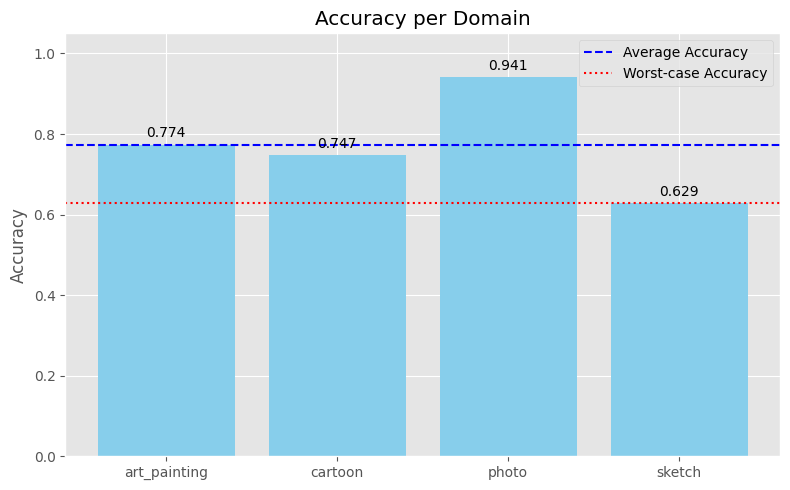

In [ ]:
import matplotlib.pyplot as plt

average_acc = sum(all_accuracies) / len(all_accuracies)
worst_acc = min(all_accuracies)

plt.style.use('ggplot')
plt.figure(figsize=(8, 5))
bars = plt.bar(PACS_DOMAINS, all_accuracies, color='skyblue')

for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2.0, yval + 0.01, f'{yval:.3f}', ha='center', va='bottom')

plt.axhline(average_acc, color='blue', linestyle='--', label='Average Accuracy')
plt.axhline(worst_acc, color='red', linestyle=':', label='Worst-case Accuracy')

plt.title("Accuracy per Domain")
plt.ylabel("Accuracy")
plt.ylim(0, 1.05)
plt.legend()
plt.tight_layout()
plt.show()
